In [13]:
import json
import os
import sys
with open("client_ip.json", "r") as f:
    client_ip = json.load(f)

In [14]:
batch_size = 128
features = 40
input_shape = (features,1)

In [15]:
import matplotlib.pyplot as plt
import numpy as np
WINDOW=256
def lstm_vector(ts1, sizes1, ts2, sizes2, voip=False, window=256):
    # 1) determine src/dst order
    if voip or ts1[0] < ts2[0]:
        src_ts, src_sizes, dst_ts, dst_sizes = ts1, sizes1, ts2, sizes2
    else:
        src_ts, src_sizes, dst_ts, dst_sizes = ts2, sizes2, ts1, sizes1

    sizes = []
    j = k = 0
    min_val = min(src_ts[0], dst_ts[0])

    # 2) merge until we have `window` events or exhaust both streams
    while len(sizes) < window:
        if j >= len(src_ts) and k >= len(dst_ts):
            break
        if j >= len(src_ts):
            sizes.append(dst_sizes[k])
            k += 1
        elif k >= len(dst_ts):
            sizes.append(src_sizes[j])
            j += 1
        elif src_ts[j] <= dst_ts[k]:
            sizes.append(src_sizes[j])
            j += 1
        else:
            sizes.append(dst_sizes[k])
            k += 1

    # 3) pad with zeros up to `window`
    if len(sizes) < window:
        sizes.extend([0] * (window - len(sizes)))

    # 4) return as (window, 1)
    return np.array(sizes, dtype=float).reshape(window, 1)

In [16]:
def check_strings_in_classname(classname):
    keywords = {
    "web": 0, "video": 1, "social": 2, "email": 3,"voip":4,"chat":5,"gaming":6,"docs":7
    }
    for keyword in keywords:
        if keyword in classname:
            return keywords[keyword] 
    return None

In [17]:
# from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.callbacks import TensorBoard, ModelCheckpoint
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout,LSTM,BatchNormalization
from keras import backend as K
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from keras.metrics import top_k_categorical_accuracy
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

def precision(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def recall(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall
def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec))

In [18]:
X_train = []
y_train = []
voip = []
gaming = []
web = []
video = []
social = []
email = []
doc = []
microsoft = []
chat = []
background = []

In [19]:
path2 = os.path.abspath('..')
import os
import csv
import tensorflow as tf

folder_path = path2+"/labeled_train"


In [20]:
import json
def traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            class_name = row[0]
            src_ip = row[1]
            src_port = row[2]
            dst_ip = row[3]
            dst_port = row[4]
            length = int(row[7])
            ts = np.array(row[8:8+length], dtype=float)
            sizes = np.array(row[9+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path and class_name == "voip":
                    y_train.append(7)
                    X_train.append(x)
                elif "gaming" in file_path:
                    y_train.append(8)
                    X_train.append(x)
                elif class_name == "web":
                    y_train.append(0)
                    X_train.append(x)
                elif class_name == "video":
                    y_train.append(1)
                    X_train.append(x)
                elif class_name == "social":
                    y_train.append(2)
                    X_train.append(x)
                elif class_name == "email":
                    y_train.append(3)
                    X_train.append(x)
                elif class_name == "doc":
                    y_train.append(4)
                    X_train.append(x)
                elif class_name == "microsoft":
                    y_train.append(5)
                    X_train.append(x)
                elif class_name == "chat":
                    y_train.append(6)
                    X_train.append(x)
                else:
                    X_train.append(x)
                    y_train.append(9)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                if class_val[key] == "voip": #if the flow is unique
                    y_train.append(7)
                    X_train.append(v)
                else:
                    y_train.append(9) #if the flow is background
                    X_train.append(v)
            elif "gaming" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                sizes = np.array(sizes, dtype=float)
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    # ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                X_train.append(v)
                y_train.append(8)
            
            
    return X_train, y_train
def iterate_over_files_in_directory(directory):
    for file_name in os.listdir(directory):
        if file_name.endswith(".csv"):  # You can adjust the file extension if needed
            file_path = os.path.join(directory, file_name)
            yield file_path


In [12]:
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)

In [13]:
import numpy as np
X_dataset = np.array(X_train)
y_dataset = np.array(y_train)


In [14]:
from collections import Counter
counter = Counter(y_dataset)
counts = [counter.get(i, 0) for i in range(10)]
max_val = max(counts)

In [15]:
for i in range(10):
    indices = np.where((y_dataset==i))[0]
    sample = X_dataset[indices]
    value = len(indices)
    print(value)
    if value==max_val:
        continue
    sampled_indices = np.random.choice(len(sample), max_val-value, replace=True)
    sampled_X = sample[sampled_indices]
    # augmented = translation(sampled_X)
    # augmented = augmented[:, :40, :]
    X_dataset = np.vstack((X_dataset,sampled_X))
    y = np.array([i]*(max_val-value))
    y_dataset = np.concatenate((y_dataset,y))

2697
466
792
113
116
239
54
289
1006
24545


In [16]:
from collections import Counter
counter = Counter(y_dataset)
counts = [counter.get(i, 0) for i in range(8)]
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_dataset, y_dataset, test_size=0.2, random_state=42)

In [ ]:
# np.save('X_train.npy', X_train)
# np.save('X_val.npy',   X_val)
# np.save('y_train.npy', y_train)
# np.save('y_val.npy',   y_val)

In [ ]:
# X_train = np.load('X_train.npy', allow_pickle=False)
# X_val   = np.load('X_val.npy',   allow_pickle=False)
# y_train = np.load('y_train.npy', allow_pickle=False)
# y_val   = np.load('y_val.npy',   allow_pickle=False)

In [22]:
X_dataset = np.concatenate((X_train,X_val))
y_dataset = np.concatenate((y_train,y_val))

In [23]:
num_classes = 10

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models,losses
import tensorflow.keras.backend as K
from tensorflow.keras import regularizers
import tensorflow as tf
from encoders import lstm_encoder,cnn_encoder,transformer_encoder,fsnet_encoder

def crc_loss(temperature=0.07):
    def loss_fn(labels, features):
        # 1) L₂‑normalize
        features = tf.math.l2_normalize(features, axis=1)
        batch_size = tf.shape(features)[0]

        # 2) Pairwise logits scaled by temperature
        logits = tf.matmul(features, features, transpose_b=True) / temperature
        # numeric stability
        logits -= tf.reduce_max(logits, axis=1, keepdims=True)

        # 3) Build positive mask
        labels = tf.reshape(labels, [batch_size, 1])
        mask = tf.cast(tf.equal(labels, tf.transpose(labels)), tf.float32)
        # remove self
        diag = tf.eye(batch_size)
        mask_no_self = mask - diag

        # 4) Hide self‑similarities in softmax
        LARGE_NUM = 1e9
        logits -= diag * LARGE_NUM

        # 5) Log‑probs
        log_prob = logits - tf.reduce_logsumexp(logits, axis=1, keepdims=True)

        # 6) Sum log‑prob over positives, and count them
        sum_log_prob_pos = tf.reduce_sum(mask_no_self * log_prob, axis=1)
        num_positives   = tf.reduce_sum(mask_no_self,     axis=1)

        # 7) Only keep anchors that actually have ≥1 positive
        valid_mask      = num_positives > 0
        sum_log_prob_pos = tf.boolean_mask(sum_log_prob_pos, valid_mask)
        num_positives    = tf.boolean_mask(num_positives,    valid_mask)

        # 8) Mean log‑prob for each valid anchor
        mean_log_prob_pos = sum_log_prob_pos / num_positives

        # 9) Final loss
        loss = -tf.reduce_mean(mean_log_prob_pos)
        return loss

    return loss_fn


encoder = fsnet_encoder()
crc_loss_fn = crc_loss(temperature=0.07)
encoder.compile(
    optimizer='adam',
    loss={
        'representation':               crc_loss_fn,
        'decoder_reconstruction': losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    loss_weights={
        'representation':               1.0,
        'decoder_reconstruction': 1.0,         # or your desired α
    }
)


checkpoint_dir = os.path.abspath('')+"/tensorboard"
log_dir = os.path.abspath('') + "/log"
MODEL_NAME = "checkpoint"
check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'fsnet_loss.weights.h5')
tensorboard = TensorBoard(log_dir='./Graph', histogram_freq=1, write_graph=True,
                          write_images=True)
checkpointer_loss = ModelCheckpoint(filepath=check_path, verbose=1, save_best_only=True,
                                     save_weights_only=True)
tensorboard.set_model(encoder)

early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True,mode='max')


In [ ]:
encoder.fit(
    X_train,
    {
        "representation": y_train,          # classification target
        "decoder_reconstruction": X_train     # reconstruction target (same as input for autoencoder)
    },
    epochs=500,
    batch_size=128,
    validation_data=(
        X_val,
        {
            "representation": y_val,
            "decoder_reconstruction": X_val
        }
    ),
    callbacks=[early_stopping, tensorboard, checkpointer_loss]
)

Epoch 1/500
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - decoder_reconstruction_loss: 1.2183 - loss: 3.7858 - representation_loss: 2.5478
Epoch 1: val_loss improved from inf to 3.74249, saving model to /nas/longleaf/home/paulchoi/labeled_2stage/tensorboard/checkpoint256fsnet_loss.weights.h5
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 10482s 7s/step - decoder_reconstruction_loss: 1.2183 - loss: 3.7857 - representation_loss: 2.5478 - val_decoder_reconstruction_loss: 1.1444 - val_loss: 3.7425 - val_representation_loss: 2.5853
Epoch 2/500
 723/1535 ━━━━━━━━━━━━━━━━━━━━ 1:25:29 6s/step - decoder_reconstruction_loss: 1.0843 - loss: 3.6239 - representation_loss: 2.5270

In [26]:
from tensorflow.keras import Input
check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'fsnet_loss.weights.h5')
encoder.load_weights(check_path)

In [27]:
X_dataset = np.array(X_dataset)

In [28]:
y_dataset = np.array(y_dataset)

In [29]:
from tqdm.auto import tqdm  # pip install tqdm

rep_extractor = tf.keras.Model(encoder.input,
                               encoder.get_layer('representation').output)

B = 1024
n = X_dataset.shape[0]
rep_dim = rep_extractor.output_shape[-1]
embeddings = np.empty((n, rep_dim), dtype='float32')

for i in tqdm(range(0, n, B), total=(n + B - 1)//B):
    batch = X_dataset[i:i+B]
    embeddings[i:i+len(batch)] = rep_extractor.predict_on_batch(batch)

  0%|          | 0/240 [00:00<?, ?it/s]

In [1]:
# embeddings = encoder.predict(X_dataset)['representation']

NameError: name 'encoder' is not defined

In [30]:
web_index = np.where(y_dataset==0)[0]
video_index = np.where(y_dataset==1)[0]
social_index = np.where(y_dataset==2)[0]
email_index = np.where(y_dataset==3)[0]
doc_index = np.where(y_dataset==4)[0]
microsoft_index = np.where(y_dataset==5)[0]
chat_index = np.where(y_dataset==6)[0]
voip_index = np.where(y_dataset==7)[0]
gaming_index = np.where(y_dataset==8)[0]
background_index = np.where(y_dataset==9)[0]

In [31]:
def cosine_similarity(vectors, reference):
    vectors_norm = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    reference_norm = reference / np.linalg.norm(reference)
    return np.dot(vectors_norm, reference_norm)
def normalize(vectors):
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)


In [34]:
all_features = normalize(embeddings)
web_embeddings               = embeddings[web_index]
video_embeddings             = embeddings[video_index]
social_embeddings            = embeddings[social_index]
email_embeddings             = embeddings[email_index]
doc_embeddings               = embeddings[doc_index]
microsoft_cloud_embeddings   = embeddings[microsoft_index]
chat_embeddings              = embeddings[chat_index]
voip_embeddings              = embeddings[voip_index]
gaming_embeddings            = embeddings[gaming_index]
background_embeddings            = embeddings[background_index]

In [35]:
from sklearn.mixture import GaussianMixture
# 2) Fit your 10-component Gaussian Mixture
gmm10 = GaussianMixture(
    n_components=10,
    covariance_type='full',
    init_params='kmeans',
    max_iter=500,
    random_state=0
)
gmm10.fit(all_features)



GaussianMixture(max_iter=500, n_components=10, random_state=0)

In [36]:
from collections import Counter

labels_train = gmm10.predict(all_features)   # array of ints in [0..9], shape (n_samples,)

category_names = [
    "web","social","email","video","ms_cloud",
    "doc","chat","voip","gaming","background"
]

cluster_label_map = {}
for k in range(gmm10.n_components):
    # indices of train samples assigned to cluster k
    idxs = np.where(labels_train == k)[0]
    if len(idxs) == 0:
        # no training points in this cluster
        cluster_label_map[k] = None  
    else:
        # find the most common true label among those points
        true_labels = [y_dataset[i] for i in idxs]
        most_common_label = Counter(true_labels).most_common(1)[0][0]
        cluster_label_map[k] = most_common_label


In [37]:
cluster_label_map

{0: np.int64(8),
 1: np.int64(6),
 2: np.int64(9),
 3: np.int64(5),
 4: np.int64(7),
 5: np.int64(2),
 6: np.int64(3),
 7: np.int64(1),
 8: np.int64(4),
 9: np.int64(0)}

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
cluster_to_true_list = {}
for k in sorted(cluster_label_map.keys()):
    idxs = np.where(labels_train == k)[0]
    true_labels_in_k = [int(y_dataset[i]) for i in idxs]
    cluster_to_true_list[k] = true_labels_in_k

# ─── 2) Sort cluster indices by their majority predicted label (None last) ────
sorted_clusters = sorted(
    cluster_to_true_list.keys(),
    key=lambda k: (
        cluster_label_map[k] is None,           # empty clusters ⇒ True ⇒ goes last
        cluster_label_map[k] if cluster_label_map[k] is not None else -1, 
        k                                        # tie‐breaker: lower cluster ID first
    )
)

# ─── 3) Print a summary in that order ────────────────────────────────────────
for k in sorted_clusters:
    true_list = cluster_to_true_list[k]
    majority = cluster_label_map[k]
    if not true_list:
        print(f"Cluster {k}:  (majority predicted label = {majority}) → no points assigned.")
        continue

    counts = Counter(true_list)
    total = len(true_list)
    print(f"\nCluster {k}:  (majority predicted label = {majority})")
    print(f"  Total points in cluster: {total}")
    print("  Breakdown of true‐labels:")
    for true_label, cnt in counts.most_common():
        pct = (cnt / total) * 100
        print(f"    True label {true_label}: {cnt} points ({pct:.2f}%)")


Cluster 9:  (majority predicted label = 0)
  Total points in cluster: 24323
  Breakdown of true‐labels:
    True label 0: 24037 points (98.82%)
    True label 9: 286 points (1.18%)

Cluster 7:  (majority predicted label = 1)
  Total points in cluster: 24563
  Breakdown of true‐labels:
    True label 1: 24545 points (99.93%)
    True label 9: 18 points (0.07%)

Cluster 5:  (majority predicted label = 2)
  Total points in cluster: 24586
  Breakdown of true‐labels:
    True label 2: 24545 points (99.83%)
    True label 9: 41 points (0.17%)

Cluster 6:  (majority predicted label = 3)
  Total points in cluster: 24607
  Breakdown of true‐labels:
    True label 3: 24545 points (99.75%)
    True label 9: 62 points (0.25%)

Cluster 8:  (majority predicted label = 4)
  Total points in cluster: 24572
  Breakdown of true‐labels:
    True label 4: 24545 points (99.89%)
    True label 9: 27 points (0.11%)

Cluster 3:  (majority predicted label = 5)
  Total points in cluster: 24566
  Breakdown of tr

In [39]:
log_likes = gmm10.score_samples(all_features)
cutoff = np.percentile(log_likes, 5)
# cutoff = np.percentile(log_likes, 10)

In [40]:
X_test = []
y_test = []
domain_name = []

In [ ]:
def test_traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            domainname = row[0]
            class_name = row[1]
            src_ip = row[2]
            src_port = row[3]
            dst_ip = row[4]
            dst_port = row[5]
            length = int(row[8])
            ts = np.array(row[9:9+length], dtype=float)
            sizes = np.array(row[10+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path and class_name == "voip":
                    y_train.append(7)
                    X_train.append(x)
                elif "gaming" in file_path:
                    y_train.append(8)
                    X_train.append(x)
                elif class_name == "web":
                    y_train.append(0)
                    X_train.append(x)
                elif class_name == "video":
                    y_train.append(1)
                    X_train.append(x)
                elif class_name == "social":
                    y_train.append(2)
                    X_train.append(x)
                elif class_name == "email":
                    y_train.append(3)
                    X_train.append(x)
                elif class_name == "doc":
                    y_train.append(4)
                    X_train.append(x)
                elif class_name == "microsoft":
                    y_train.append(5)
                    X_train.append(x)
                elif class_name == "chat":
                    y_train.append(6)
                    X_train.append(x)
                else:
                    X_train.append(x)
                    y_train.append(9)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if key[1] == "5353":
            continue
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                if class_val[key] == "voip": #if the flow is unique
                    y_train.append(7)
                    X_train.append(v)
                else:
                    y_train.append(9) #if the flow is background
                    X_train.append(v)
            elif "gaming" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                sizes = np.array(sizes, dtype=float)
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    # ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                X_train.append(v)
                y_train.append(8)
            
            
    return X_train, y_train

In [ ]:
folder_path = os.path.abspath('..')+"/domain_labeled_test"
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)

In [37]:
X_test = np.array(X_test)

In [38]:
test_embeddings,_ = encoder.predict(X_test)

367/367 ━━━━━━━━━━━━━━━━━━━━ 168s 452ms/step


2025-07-24 17:21:29.173151: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 18004699136 exceeds 10% of free system memory.


In [39]:
test_embeddings = normalize(test_embeddings)

In [40]:
labels_test = gmm10.predict(test_embeddings)

# b) map each cluster to a predicted label index
y_pred = [
    cluster_label_map[k] if cluster_label_map[k] is not None else -1
    for k in labels_test
]


In [41]:
cluster_label_map

{0: np.int64(8),
 1: np.int64(2),
 2: np.int64(7),
 3: np.int64(6),
 4: np.int64(5),
 5: np.int64(1),
 6: np.int64(3),
 7: np.int64(4),
 8: np.int64(0),
 9: np.int64(9)}

In [42]:
np.unique(y_pred)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
macro_f1 = round(f1_score(y_test, y_pred, average='macro'), 2)
accuracy = round(accuracy_score(y_test, y_pred), 2)
average_f1 = round(f1_score(y_test, y_pred, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print or use the evaluation metrics as needed
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')

Macro Average F1 Score: 0.83
Accuracy: 0.95
Weighted Average F1 Score: 0.95


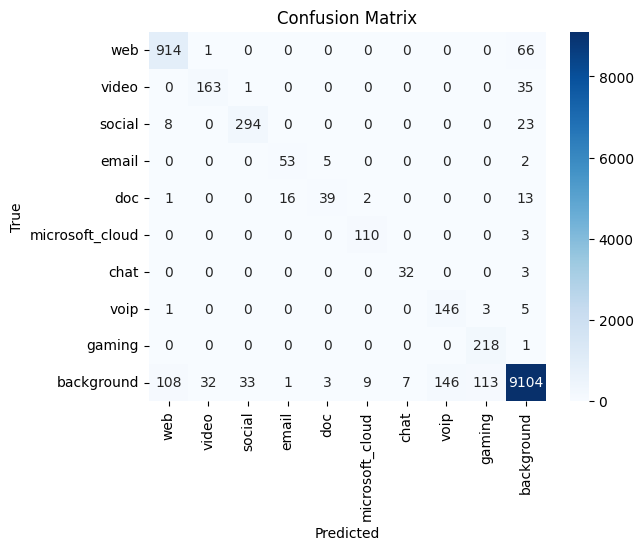

In [44]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background'], yticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('fs_net_gmm.png', dpi=300, bbox_inches='tight')
plt.show()

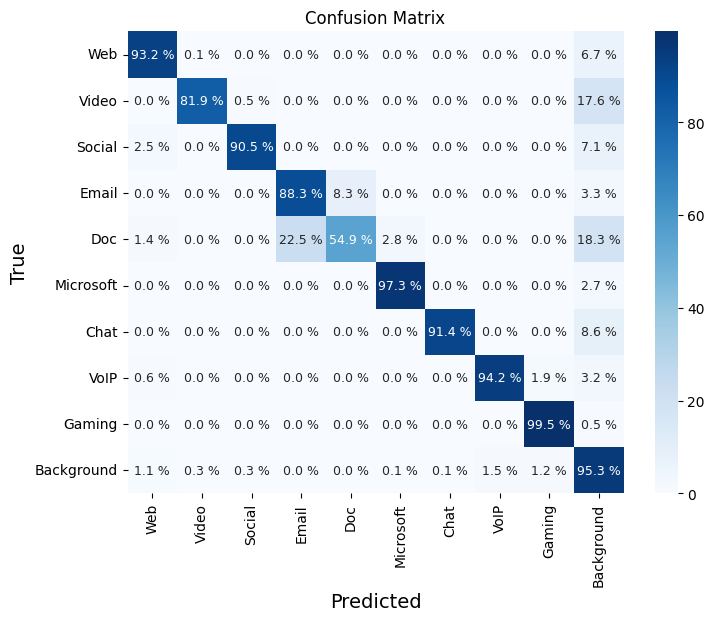

In [45]:
conf_matrix_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 9}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.show()

In [46]:
y_pred = np.array(y_pred)
y_test = np.array(y_test)

In [47]:
per_class_acc = {}
for cls in np.unique(y_test):
    # find all positions where the true label is cls
    idx = np.where(y_test == cls)[0]
    # fraction of those that were correctly predicted
    per_class_acc[cls] = np.mean(y_pred[idx] == y_test[idx]) * 100

# print results
for cls, acc in per_class_acc.items():
    print(f"Label {cls}: {acc:.2f}% correct")

Label 0: 93.17% correct
Label 1: 81.91% correct
Label 2: 90.46% correct
Label 3: 88.33% correct
Label 4: 54.93% correct
Label 5: 97.35% correct
Label 6: 91.43% correct
Label 7: 94.19% correct
Label 8: 99.54% correct
Label 9: 95.27% correct


In [48]:
total = len(y_test)

for cls in np.unique(y_test):
    idx       = np.where(y_test == cls)[0]
    count_i   = len(idx)
    correct_i = np.sum(y_pred[idx] == cls)
    acc_i     = 100 * correct_i / count_i
    print(f"Label {cls}: {count_i}/{total} flows,  {correct_i}/{count_i} correct  ({acc_i:.2f}%)")

print(f"\nOverall: {np.sum(y_pred == y_test)}/{total} correct  ({100*np.mean(y_pred==y_test):.2f}%)")

Label 0: 981/11714 flows,  914/981 correct  (93.17%)
Label 1: 199/11714 flows,  163/199 correct  (81.91%)
Label 2: 325/11714 flows,  294/325 correct  (90.46%)
Label 3: 60/11714 flows,  53/60 correct  (88.33%)
Label 4: 71/11714 flows,  39/71 correct  (54.93%)
Label 5: 113/11714 flows,  110/113 correct  (97.35%)
Label 6: 35/11714 flows,  32/35 correct  (91.43%)
Label 7: 155/11714 flows,  146/155 correct  (94.19%)
Label 8: 219/11714 flows,  218/219 correct  (99.54%)
Label 9: 9556/11714 flows,  9104/9556 correct  (95.27%)

Overall: 11073/11714 correct  (94.53%)


In [51]:
percentile_per_cluster = {}
for k in range(gmm10.n_components):
    idxs = np.where(labels_train == k)[0]
    if len(idxs) == 0 or cluster_label_map.get(k) is None:
        percentile_per_cluster[k] = None
    else:
        p = 5
        percentile_per_cluster[k] = np.percentile(log_likes[idxs], p)

In [53]:
log_likes_test = gmm10.score_samples(test_embeddings)  # shape (n_test,)
labels_test = gmm10.predict(test_embeddings)
y_pred2 = [
    cluster_label_map[k]
    if (percentile_per_cluster.get(k) is not None
        and log_likes_test[i] >= percentile_per_cluster[k])
        # and log_likes_test[i] >= cutoff)

    else 10
    for i, k in enumerate(labels_test)
]

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
macro_f1 = round(f1_score(y_test, y_pred2, average='macro'), 2)
accuracy = round(accuracy_score(y_test, y_pred2), 2)
average_f1 = round(f1_score(y_test, y_pred2, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
f1 = f1_score(y_test, y_pred2, average=None)
conf_matrix = confusion_matrix(y_test, y_pred2)

# Print or use the evaluation metrics as needed
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')

Macro Average F1 Score: 0.72
Accuracy: 0.87
Weighted Average F1 Score: 0.92


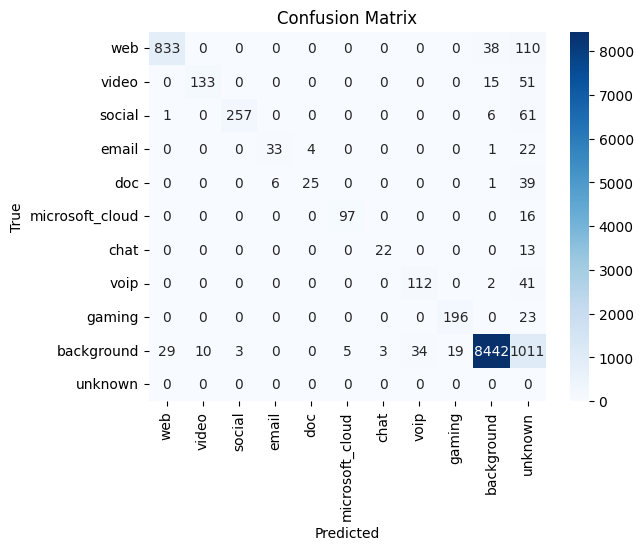

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred2)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background','unknown'], yticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background','unknown'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [56]:
y_pred2=np.array(y_pred2)

In [57]:
np.unique(y_pred2)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [58]:
total = len(y_test)
total_flows = 0
for cls in np.unique(y_test):
    idx       = np.where(y_test == cls)[0]
    count_i   = len(idx)
    correct_i = np.sum(y_pred2[idx] == cls)
    acc_i     = 100 * correct_i / count_i
    print(f"Label {cls}: {count_i}/{total} flows,  {correct_i}/{count_i} covered  ({acc_i:.2f}%)")
    total_flows+=correct_i

print(f"\nOverall: {total_flows}/{total} covered  ({100*total_flows/total:.2f}%)")

Label 0: 981/11714 flows,  833/981 covered  (84.91%)
Label 1: 199/11714 flows,  133/199 covered  (66.83%)
Label 2: 325/11714 flows,  257/325 covered  (79.08%)
Label 3: 60/11714 flows,  33/60 covered  (55.00%)
Label 4: 71/11714 flows,  25/71 covered  (35.21%)
Label 5: 113/11714 flows,  97/113 covered  (85.84%)
Label 6: 35/11714 flows,  22/35 covered  (62.86%)
Label 7: 155/11714 flows,  112/155 covered  (72.26%)
Label 8: 219/11714 flows,  196/219 covered  (89.50%)
Label 9: 9556/11714 flows,  8442/9556 covered  (88.34%)

Overall: 10150/11714 covered  (86.65%)


/tmp/ipykernel_65917/1421336308.py:1: RuntimeWarning: invalid value encountered in divide
  conf_matrix_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


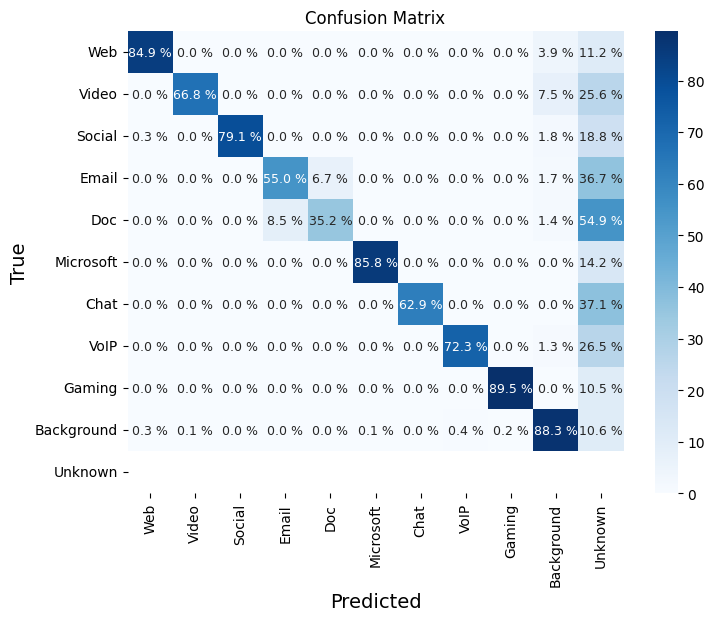

In [59]:
conf_matrix_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background","Unknown"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 9}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.show()

In [60]:
y_pred2 = np.array(y_pred2)

In [61]:
domain_name = np.array(domain_name)

In [62]:
unknown_idx = 10
# build a boolean mask for all predictions that are NOT "unknown"
mask = (y_pred2 != unknown_idx)
y_test = np.array(y_test)
# apply it to both ground‐truth and prediction arrays
y_true_masked = y_test[mask]
y_pred_masked = y_pred2[mask]
# domain_name_masked = domain_name[mask]
# now compute metrics on the filtered set
macro_f1       = round(f1_score(y_true_masked, y_pred_masked, average='macro'), 2)
accuracy       = round(accuracy_score(y_true_masked, y_pred_masked), 2)
weighted_f1    = round(f1_score(y_true_masked, y_pred_masked, average='weighted'), 2)
per_class_f1   = f1_score(y_true_masked, y_pred_masked, average=None)
conf_matrix    = confusion_matrix(y_true_masked, y_pred_masked)

print(f'Macro F1:   {macro_f1}')
print(f'Accuracy:   {accuracy}')
print(f'Weighted F1:{weighted_f1}')


Macro F1:   0.92
Accuracy:   0.98
Weighted F1:0.98


In [63]:
len(y_pred_masked)

10327

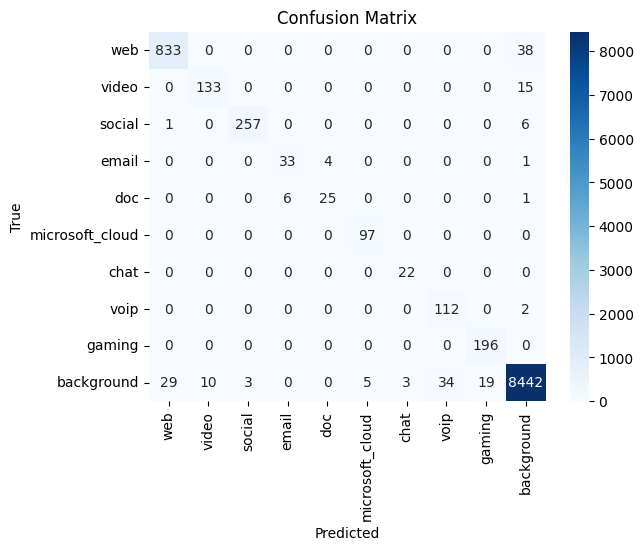

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_true_masked, y_pred_masked)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background'], yticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('filtered_fs_net_gmm.png', dpi=300, bbox_inches='tight')
plt.show()

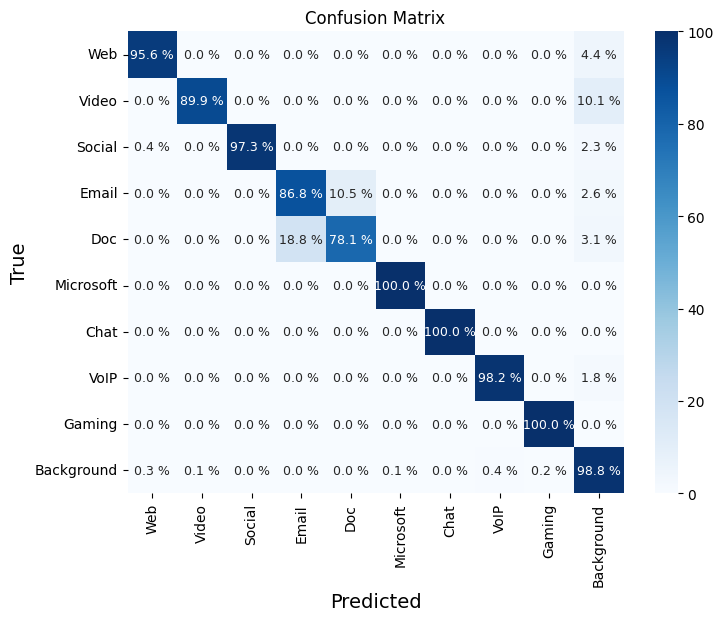

In [65]:
conf_matrix_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 9}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.show()